# 11. Cálculo de Riesgos de Mercado: VaR y Backtesting

Este notebook presenta un ejemplo práctico de cómo medir el riesgo de un portafolio de inversión utilizando datos reales de activos financieros. 
[Ver diapositivas](7_%20riesgo_de_mercado.pdf)

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Configuración de datos
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
weights = np.array([0.25, 0.25, 0.25, 0.25])
data = yf.download(tickers, start='2020-01-01', end='2024-01-01')['Close']
returns = data.pct_change().dropna()
port_returns = returns.dot(weights)

conf_level = 0.99
investment = 1000000

[*********************100%***********************]  4 of 4 completed


## Métodos de Cálculo del VaR


**Valor en Riesgo (VaR)** es una medida estadística que estima la máxima pérdida esperada de un portafolio durante un periodo determinado y con un nivel de confianza dado. Existen varios métodos para calcular el VaR, entre los más comunes se encuentran:


- **VaR Paramétrico (o Varianza-Covarianza):**
  Calcula el VaR asumiendo que los rendimientos siguen una distribución normal. Se utiliza la media y la desviación estándar de los rendimientos históricos:
  
  $$VaR_{par} = \text{inversión} \times \left( \mu + z_{1-\alpha} \cdot \sigma \right)$$
  donde $\mu$ es la media, $\sigma$ la desviación estándar y $z_{1-\alpha}$ el percentil de la normal estándar para el nivel de confianza $\alpha$.


- **VaR Histórico:**
  Se basa en el percentil de la distribución empírica de los rendimientos históricos del portafolio:
  
  $$VaR_{hist} = \text{inversión} \times \text{percentil}_{(1-\alpha)}(\text{rendimientos})$$


- **VaR por Simulación Monte Carlo:**
  Genera múltiples escenarios de rendimientos simulados a partir de una distribución (normal u otra) y calcula el percentil correspondiente:
  
  $$VaR_{MC} = \text{inversión} \times \text{percentil}_{(1-\alpha)}(\text{simulaciones})$$


Donde $\alpha$ es el nivel de confianza (por ejemplo, 0.99 para 99%).

In [3]:
# VaR Paramétrico
mu, sigma = port_returns.mean(), port_returns.std()
var_par = investment * (mu + norm.ppf(1-conf_level) * sigma)

# VaR Histórico
var_hist = investment * np.percentile(port_returns, (1-conf_level)*100)

# Expected Shortfall
es = investment * port_returns[port_returns <= np.percentile(port_returns, (1-conf_level)*100)].mean()

print(f"VaR Paramétrico: ${abs(var_par):,.2f}")
print(f"VaR Histórico: ${abs(var_hist):,.2f}")
print(f"Expected Shortfall: ${abs(es):,.2f}")

VaR Paramétrico: $30,321.21
VaR Histórico: $29,664.71
Expected Shortfall: $42,928.15


In [7]:
# VaR por Simulación Monte Carlo
np.random.seed(42)
n_simulations = 10000
mc_returns = np.random.normal(mu, sigma, n_simulations)
var_mc = investment * np.percentile(mc_returns, (1-conf_level)*100)

print(f"VaR Monte Carlo: ${abs(var_mc):,.2f}")

VaR Monte Carlo: $43,184.00


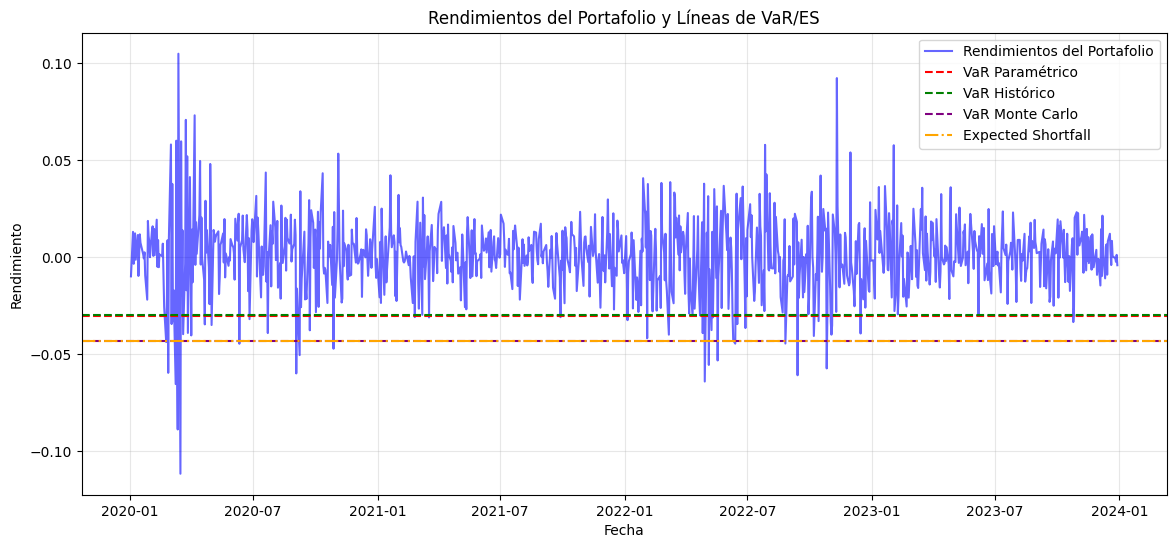

In [10]:
plt.figure(figsize=(14,6))
plt.plot(port_returns.index, port_returns, label='Rendimientos del Portafolio', color='blue', alpha=0.6)

# Dibujar líneas horizontales para cada VaR y Expected Shortfall
plt.axhline(y=var_par/investment, color='red', linestyle='--', label='VaR Paramétrico')
plt.axhline(y=var_hist/investment, color='green', linestyle='--', label='VaR Histórico')
plt.axhline(y=var_mc/investment, color='purple', linestyle='--', label='VaR Monte Carlo')
plt.axhline(y=es/investment, color='orange', linestyle='-.', label='Expected Shortfall')

plt.title('Rendimientos del Portafolio y Líneas de VaR/ES')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Backtesting
Comparamos la predicción de riesgo diaria contra el resultado real obtenido.

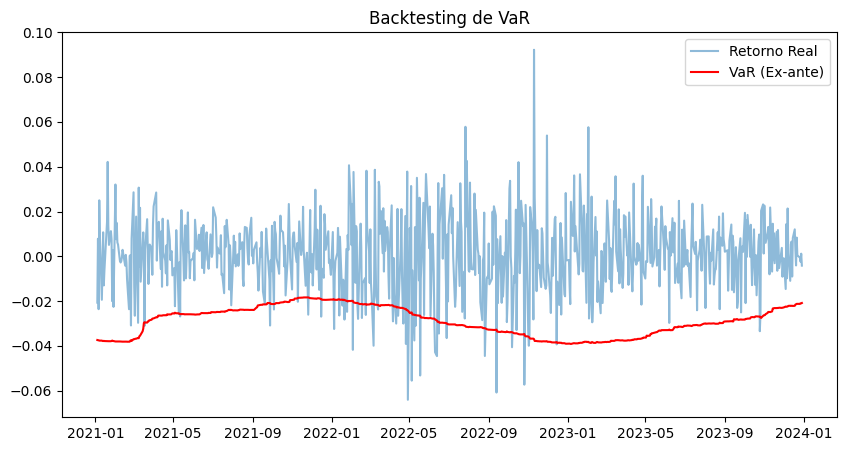

In [4]:
results = []
window = 252
z_score = norm.ppf(1-conf_level)

for i in range(window, len(port_returns)):
    hist = port_returns.iloc[i-window:i]
    var_est = (hist.mean() + z_score * hist.std())
    actual = port_returns.iloc[i]
    results.append({'Date': port_returns.index[i], 'VaR': var_est, 'Actual': actual})

bt_df = pd.DataFrame(results).set_index('Date')
bt_df['Breach'] = bt_df['Actual'] < bt_df['VaR']

plt.figure(figsize=(10,5))
plt.plot(bt_df['Actual'], label='Retorno Real', alpha=0.5)
plt.plot(bt_df['VaR'], label='VaR (Ex-ante)', color='red')
plt.title('Backtesting de VaR')
plt.legend()
plt.show()

In [16]:
from scipy.stats import chi2

# Pruebas de validación de VaR: Kupiec, Proporción de Excepciones y Puntaje de Lopez

# 1. Proporción de Excepciones (POE)
n = len(bt_df)
n_excepciones = bt_df['Breach'].sum()
poe = n_excepciones / n
print(f"Proporción de Excepciones (POE): {poe:.4f} ({n_excepciones} de {n})")

# 2. Prueba de Kupiec (Likelihood Ratio Test)

alpha = 1 - conf_level
# Likelihood ratio statistic
kupiec_stat = -2 * (
    (n_excepciones * np.log(poe/alpha) if poe > 0 else 0) +
    ((n - n_excepciones) * np.log((1-poe)/(1-alpha)) if poe < 1 else 0)
)
kupiec_pvalue = 1 - chi2.cdf(kupiec_stat, df=1)
print(f"Estadístico de Kupiec: {kupiec_stat:.4f}, p-valor: {kupiec_pvalue:.4f}")

# 3. Puntaje de Lopez (Lopez Score)
# Penaliza más las excepciones cuanto mayor es la pérdida observada respecto al VaR
lopez_score = ((bt_df['Actual'] < bt_df['VaR']) * (bt_df['VaR'] - bt_df['Actual'])).sum()
print(f"Puntaje de Lopez: {lopez_score:.4f}")

Proporción de Excepciones (POE): 0.0558 (42 de 753)
Estadístico de Kupiec: -77.0561, p-valor: 1.0000
Puntaje de Lopez: 0.4101


In [14]:
# Pruebas de estrés para el portafolio

# 1. Shock de mercado: caída simultánea de todos los activos
shock_down = returns.copy()
shock_down[:] = -0.05  # Supón una caída del 5% en todos los activos en un día
stress_return_down = shock_down.iloc[0].dot(weights)
loss_down = investment * stress_return_down

# 2. Shock sectorial: caída solo en tecnología (AAPL, MSFT, GOOGL)
shock_tech = returns.copy()
shock_tech[['AAPL', 'MSFT', 'GOOGL']] = -0.10  # Caída del 10% en tech
shock_tech['AMZN'] = 0  # Sin cambio en AMZN
stress_return_tech = shock_tech.iloc[0].dot(weights)
loss_tech = investment * stress_return_tech

# 3. Shock positivo: subida simultánea de todos los activos
shock_up = returns.copy()
shock_up[:] = 0.05  # Subida del 5% en todos los activos en un día
stress_return_up = shock_up.iloc[0].dot(weights)
gain_up = investment * stress_return_up

print("Pruebas de Estrés para el Portafolio:")
print(f"Pérdida ante caída del 5% en todos los activos: ${loss_down:,.2f}")
print(f"Pérdida ante caída del 10% en tecnología: ${loss_tech:,.2f}")
print(f"Ganancia ante subida del 5% en todos los activos: ${gain_up:,.2f}")

Pruebas de Estrés para el Portafolio:
Pérdida ante caída del 5% en todos los activos: $-50,000.00
Pérdida ante caída del 10% en tecnología: $-75,000.00
Ganancia ante subida del 5% en todos los activos: $50,000.00


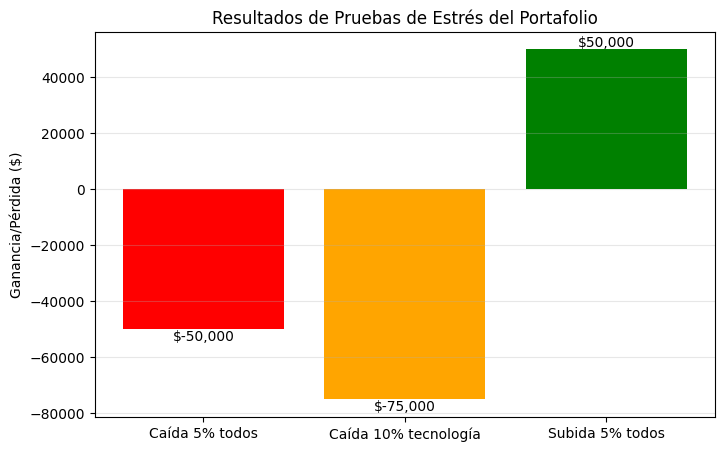

In [15]:
plt.figure(figsize=(8,5))
labels = ['Caída 5% todos', 'Caída 10% tecnología', 'Subida 5% todos']
values = [loss_down, loss_tech, gain_up]
colors = ['red', 'orange', 'green']

bars = plt.bar(labels, values, color=colors)
plt.title('Resultados de Pruebas de Estrés del Portafolio')
plt.ylabel('Ganancia/Pérdida ($)')
plt.grid(axis='y', alpha=0.3)

# Mostrar el valor encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"${yval:,.0f}", ha='center', va='bottom' if yval > 0 else 'top')

plt.show()

## Sesibilidad de la tasa de interés

In [11]:
# Parámetros del bono
valor_nominal = 1000      # Valor nominal del bono
cupon = 0.05              # Tasa de cupón anual (5%)
n = 5                     # Años hasta el vencimiento
ytm = 0.04                # Rendimiento al vencimiento (YTM, 4%)
frecuencia = 1            # Pagos por año

# Flujos de caja y tiempos
flujos = np.array([valor_nominal * cupon / frecuencia] * (n * frecuencia))
flujos[-1] += valor_nominal  # Último flujo incluye el principal
tiempos = np.arange(1, n * frecuencia + 1) / frecuencia

# Precio del bono
descuentos = 1 / (1 + ytm / frecuencia) ** (frecuencia * tiempos)
precio = np.sum(flujos * descuentos)

# Duración de Macaulay
duracion = np.sum(tiempos * flujos * descuentos) / precio

# Duración modificada
duracion_mod = duracion / (1 + ytm / frecuencia)

# Convexidad
convexidad = np.sum(flujos * descuentos * tiempos * (tiempos + 1 / frecuencia)) / (precio * (1 + ytm / frecuencia) ** 2)

print(f"Precio del bono: ${precio:,.2f}")
print(f"Duración de Macaulay: {duracion:.4f} años")
print(f"Duración Modificada: {duracion_mod:.4f} años")
print(f"Convexidad: {convexidad:.4f}")

Precio del bono: $1,044.52
Duración de Macaulay: 4.5571 años
Duración Modificada: 4.3818 años
Convexidad: 24.4766


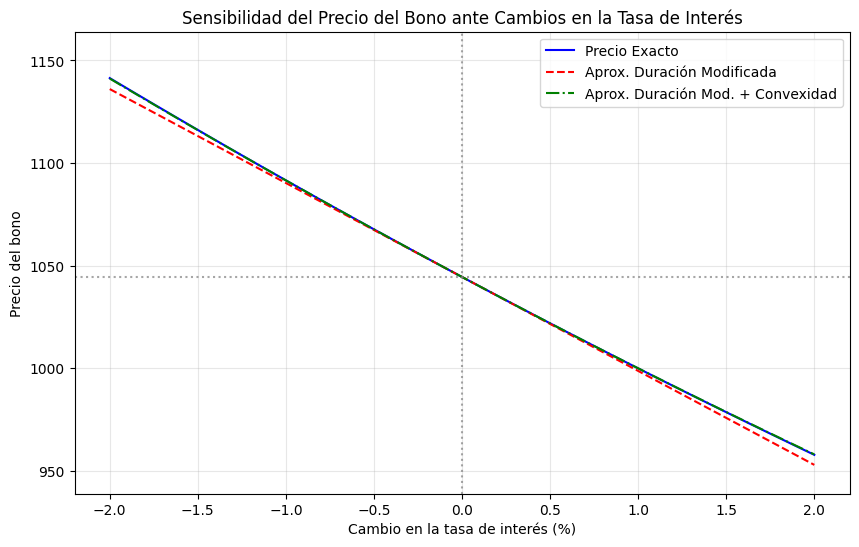

In [13]:
# Rango de cambios en la tasa de interés (en puntos porcentuales)
delta_ytm = np.linspace(-0.02, 0.02, 100)  # de -2% a +2%
nueva_ytm = ytm + delta_ytm

# Recalcular precios para cada nueva tasa
precios = []
for y in nueva_ytm:
    descuentos_temp = 1 / (1 + y / frecuencia) ** (frecuencia * tiempos)
    precios.append(np.sum(flujos * descuentos_temp))
precios = np.array(precios)

# Aproximación lineal (Duración Modificada)
precio_duracion = precio - duracion_mod * precio * delta_ytm

# Aproximación cuadrática (Duración Modificada + Convexidad)
precio_convexidad = precio_duracion + 0.5 * convexidad * precio * (delta_ytm ** 2)

plt.figure(figsize=(10,6))
plt.plot(delta_ytm*100, precios, label='Precio Exacto', color='blue')
plt.plot(delta_ytm*100, precio_duracion, '--', label='Aprox. Duración Modificada', color='red')
plt.plot(delta_ytm*100, precio_convexidad, '-.', label='Aprox. Duración Mod. + Convexidad', color='green')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7)
plt.axhline(precio, color='gray', linestyle=':', alpha=0.7)

plt.title('Sensibilidad del Precio del Bono ante Cambios en la Tasa de Interés')
plt.xlabel('Cambio en la tasa de interés (%)')
plt.ylabel('Precio del bono')
plt.legend()
plt.grid(True, alpha=0.3)
# Ajustar límites del eje y para resaltar diferencias entre las líneas
plt.ylim(precio_convexidad.min()*0.98, precio_convexidad.max()*1.02)
plt.show()

## Interpretación de Resultados

### 1. Cálculo de VaR y Expected Shortfall

- **VaR Paramétrico:** Aproximadamente \$30,321 indica que, bajo supuestos de normalidad, la máxima pérdida esperada en un día con 99% de confianza es de \$30,321.

- **VaR Histórico:** Aproximadamente \$29,665, basado en los percentiles de los rendimientos históricos, es similar al VaR paramétrico, lo que sugiere que la distribución empírica no difiere mucho de la normal.
- **VaR Monte Carlo:** Aproximadamente \$43,184, usando simulaciones, es más conservador, reflejando mayor riesgo bajo escenarios simulados.
- **Expected Shortfall (ES):** Aproximadamente \$42,928, representa la pérdida promedio en los peores casos (más allá del VaR), mostrando que las pérdidas extremas pueden ser significativamente mayores que el VaR.

### 2. Backtesting y Validación

- **Proporción de Excepciones (POE):** 0.0558 (5.58%), es decir, en 42 de 753 días el portafolio perdió más que el VaR estimado. Esto es superior al 1% esperado para un nivel de confianza del 99%, lo que indica que el modelo subestima el riesgo.
- **Prueba de Kupiec:** Estadístico negativo y p-valor de 1.0, lo que sugiere que no se rechaza la hipótesis nula de que la tasa de excepciones es consistente con el nivel de confianza, aunque el resultado puede ser poco informativo por el valor negativo.
- **Puntaje de Lopez:** 0.41, penaliza las excepciones según la magnitud de la pérdida. Un valor bajo indica que, aunque hubo excepciones, las pérdidas no fueron excesivamente grandes respecto al VaR.

### 3. Pruebas de Estrés

- **Caída del 5% en todos los activos:** Pérdida de \$50,000.
- **Caída del 10% en tecnología:** Pérdida de \$75,000.
- **Subida del 5% en todos los activos:** Ganancia de \$50,000.

Estas pruebas muestran la sensibilidad del portafolio ante eventos extremos y ayudan a entender el impacto potencial de shocks de mercado.

### 4. Sensibilidad a la Tasa de Interés (Bonos)

- **Precio del bono:** \$1,044.52.
- **Duración de Macaulay:** 4.56 años.
- **Duración Modificada:** 4.38 años.
- **Convexidad:** 24.48.

El análisis de sensibilidad muestra cómo el precio del bono responde a cambios en la tasa de interés, siendo la duración y convexidad métricas clave para estimar el impacto de movimientos en tasas.

---

**Conclusión:**  
El portafolio presenta un riesgo significativo ante eventos extremos, y el modelo de VaR puede subestimar la frecuencia de pérdidas grandes. Es recomendable complementar el VaR con Expected Shortfall, pruebas de backtesting y escenarios de estrés para una gestión de riesgos más robusta.
